In [1]:
# Healthcare EDA: Early Stage Diabetes Dataset

## 1. Load the Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes_data_upload.csv')

In [3]:
## 2. Inspect the Dataset

In [4]:
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [5]:
df.shape

(520, 17)

In [6]:
df.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    str  
 2   Polyuria            520 non-null    str  
 3   Polydipsia          520 non-null    str  
 4   sudden weight loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   Polyphagia          520 non-null    str  
 7   Genital thrush      520 non-null    str  
 8   visual blurring     520 non-null    str  
 9   Itching             520 non-null    str  
 10  Irritability        520 non-null    str  
 11  delayed healing     520 non-null    str  
 12  partial paresis     520 non-null    str  
 13  muscle stiffness    520 non-null    str  
 14  Alopecia            520 non-null    str  
 15  Obesity             520 non-null    str  
 16  class               520 non-null    str  
dtypes: int64

In [8]:
df.dtypes

Age                   int64
Gender                  str
Polyuria                str
Polydipsia              str
sudden weight loss      str
weakness                str
Polyphagia              str
Genital thrush          str
visual blurring         str
Itching                 str
Irritability            str
delayed healing         str
partial paresis         str
muscle stiffness        str
Alopecia                str
Obesity                 str
class                   str
dtype: object

In [9]:
df.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [10]:
df['class'].value_counts()

class
Positive    320
Negative    200
Name: count, dtype: int64

In [11]:
df['Polyuria'].value_counts()

Polyuria
No     262
Yes    258
Name: count, dtype: int64

In [12]:
df.groupby('class')['Polyuria'].value_counts()

class     Polyuria
Negative  No          185
          Yes          15
Positive  Yes         243
          No           77
Name: count, dtype: int64

In [13]:
df.groupby('class')['Age'].mean()

class
Negative    46.360000
Positive    49.071875
Name: Age, dtype: float64

In [14]:
## 3. Data Quality & Cleaning

In [15]:
df.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [16]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [17]:
df['Gender'].value_counts()

Gender
Male      328
Female    192
Name: count, dtype: int64

In [18]:
df.nunique()

Age                   51
Gender                 2
Polyuria               2
Polydipsia             2
sudden weight loss     2
weakness               2
Polyphagia             2
Genital thrush         2
visual blurring        2
Itching                2
Irritability           2
delayed healing        2
partial paresis        2
muscle stiffness       2
Alopecia               2
Obesity                2
class                  2
dtype: int64

In [19]:
new_column = [old_column.lower().replace(" ","_") for old_column in df.columns]
#new_columns = [column.lower().replace(" ", "_") for column in df.columns]

df.columns = new_column
df.columns

Index(['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
       'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
       'itching', 'irritability', 'delayed_healing', 'partial_paresis',
       'muscle_stiffness', 'alopecia', 'obesity', 'class'],
      dtype='str')

In [20]:
df.duplicated().sum()

np.int64(269)

In [21]:
df.duplicated().value_counts()

# This dataset has 269 rows that are identical to a previous row. 
# Becuase there is no patient indicator, identical rows cannot be confirmed as duplicates, therefore will be retained.

True     269
False    251
Name: count, dtype: int64

In [22]:
## 4. Exploratory Data Analysis

In [23]:
df['age'].mean()

np.float64(48.02884615384615)

In [24]:
df['age'].median()

# The mean and median ages are very similar (~48 years), suggesting the distribution is not strongly skewed. 
# A visualization is needed to assess the distribution and potential outliers more carefully. 

np.float64(47.5)

<Axes: xlabel='age', ylabel='Count'>

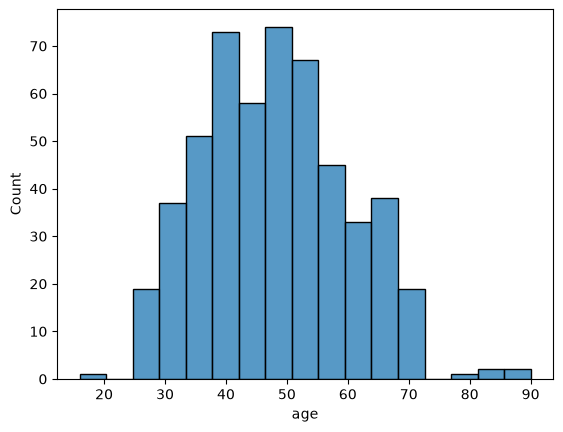

In [25]:
sns.histplot(
    x = df['age']
)

# Most patients are roughly between 35-55 years old. The distribution appears approximately symmertric, with some patients extending into the 80's
# The mean and median being close supports the observation that the data is not strongly skewed.

<Axes: xlabel='class', ylabel='count'>

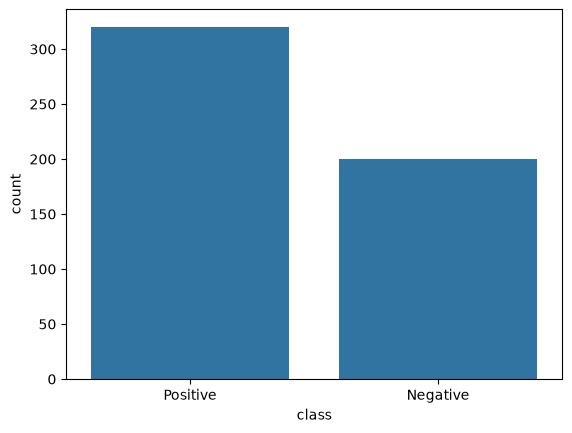

In [26]:
sns.countplot(
    x = df['class']
)

# The dataset contains 320 Positive and 200 Negative cases, meaning approximately 61.5% of observations are Positive.
# The groups are somewhat imbalanced, so raw counts should be considered carefully when comparing groups.

In [27]:
for column in df.columns:
    if column != 'age': #trying to get rid of age row
        print(f'{df[column].value_counts()} \n')
       

gender
Male      328
Female    192
Name: count, dtype: int64 

polyuria
No     262
Yes    258
Name: count, dtype: int64 

polydipsia
No     287
Yes    233
Name: count, dtype: int64 

sudden_weight_loss
No     303
Yes    217
Name: count, dtype: int64 

weakness
Yes    305
No     215
Name: count, dtype: int64 

polyphagia
No     283
Yes    237
Name: count, dtype: int64 

genital_thrush
No     404
Yes    116
Name: count, dtype: int64 

visual_blurring
No     287
Yes    233
Name: count, dtype: int64 

itching
No     267
Yes    253
Name: count, dtype: int64 

irritability
No     394
Yes    126
Name: count, dtype: int64 

delayed_healing
No     281
Yes    239
Name: count, dtype: int64 

partial_paresis
No     296
Yes    224
Name: count, dtype: int64 

muscle_stiffness
No     325
Yes    195
Name: count, dtype: int64 

alopecia
No     341
Yes    179
Name: count, dtype: int64 

obesity
No     432
Yes     88
Name: count, dtype: int64 

class
Positive    320
Negative    200
Name: count, dtype: in

In [28]:
## 5. Feature Relationships

In [29]:
df.groupby("class")["polyuria"].value_counts(normalize = True)

# Polyuria was reported for approximately 76% of Positive cases while ony 7.5% of Negative cases.
# This shows a strong association between polyuria and diabetes classification in this dataset

class     polyuria
Negative  No          0.925000
          Yes         0.075000
Positive  Yes         0.759375
          No          0.240625
Name: proportion, dtype: float64

In [30]:
for column in df.columns:
    if column not in ['age', 'gender', 'class']:
        print(f'{df.groupby('class')[column].value_counts(normalize = True)} \n\n')

class     polyuria
Negative  No          0.925000
          Yes         0.075000
Positive  Yes         0.759375
          No          0.240625
Name: proportion, dtype: float64 


class     polydipsia
Negative  No            0.960000
          Yes           0.040000
Positive  Yes           0.703125
          No            0.296875
Name: proportion, dtype: float64 


class     sudden_weight_loss
Negative  No                    0.8550
          Yes                   0.1450
Positive  Yes                   0.5875
          No                    0.4125
Name: proportion, dtype: float64 


class     weakness
Negative  No          0.56500
          Yes         0.43500
Positive  Yes         0.68125
          No          0.31875
Name: proportion, dtype: float64 


class     polyphagia
Negative  No            0.760000
          Yes           0.240000
Positive  Yes           0.590625
          No            0.409375
Name: proportion, dtype: float64 


class     genital_thrush
Negative  No          

In [31]:
results = []

for column in df.columns:
    if column not in ['age', 'gender', 'class']:
        x = df.groupby('class')[column].value_counts(normalize = True)
        pos_yes = x['Positive', 'Yes']
        neg_yes = x['Negative', 'Yes']
        results.append([column, neg_yes, pos_yes]) 

In [32]:
df2 = pd.DataFrame(
    results,
    columns = ['symptom', 'negative_grp', 'positive_grp']
)

df2

,symptom,negative_grp,positive_grp
0,polyuria,0.075,0.759375
1,polydipsia,0.040,0.703125
2,sudden_weight_loss,0.145,0.587500
3,weakness,0.435,0.681250
4,polyphagia,0.240,0.590625
5,genital_thrush,0.165,0.259375
6,visual_blurring,0.290,0.546875
7,itching,0.495,0.481250
8,irritability,0.080,0.343750
9,delayed_healing,0.430,0.478125


In [33]:
df2['difference'] = (df2['negative_grp'] - df2['positive_grp']).abs()

df2.sort_values('difference', ascending = False)

,symptom,negative_grp,positive_grp,difference
0,polyuria,0.075,0.759375,0.684375
1,polydipsia,0.040,0.703125,0.663125
2,sudden_weight_loss,0.145,0.587500,0.442500
10,partial_paresis,0.160,0.600000,0.440000
4,polyphagia,0.240,0.590625,0.350625
8,irritability,0.080,0.343750,0.263750
12,alopecia,0.505,0.243750,0.261250
6,visual_blurring,0.290,0.546875,0.256875
3,weakness,0.435,0.681250,0.246250
11,muscle_stiffness,0.300,0.421875,0.121875


In [34]:
# Largest differences: polyuria, polydipsia, partial_paresis
# Smallest difference: itching
# Higher in Negative: itching and alopecia

In [35]:
df2.head()

,symptom,negative_grp,positive_grp,difference
0,polyuria,0.075,0.759375,0.684375
1,polydipsia,0.040,0.703125,0.663125
2,sudden_weight_loss,0.145,0.587500,0.442500
3,weakness,0.435,0.681250,0.246250
4,polyphagia,0.240,0.590625,0.350625


In [36]:
df_long = df2.melt(
    id_vars = 'symptom',
    value_vars = ['negative_grp', 'positive_grp'],
    var_name = 'class',
    value_name = 'percentage'
)

df_long['class'] = df_long['class'].replace({
    'negative_grp': 'negative',
    'positive_grp': 'positive'
})

df_long.head()

,symptom,class,percentage
0,polyuria,negative,0.075
1,polydipsia,negative,0.040
2,sudden_weight_loss,negative,0.145
3,weakness,negative,0.435
4,polyphagia,negative,0.240


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'polyuria'),
  Text(1, 0, 'polydipsia'),
  Text(2, 0, 'sudden_weight_loss'),
  Text(3, 0, 'weakness'),
  Text(4, 0, 'polyphagia'),
  Text(5, 0, 'genital_thrush'),
  Text(6, 0, 'visual_blurring'),
  Text(7, 0, 'itching'),
  Text(8, 0, 'irritability'),
  Text(9, 0, 'delayed_healing'),
  Text(10, 0, 'partial_paresis'),
  Text(11, 0, 'muscle_stiffness'),
  Text(12, 0, 'alopecia'),
  Text(13, 0, 'obesity')])

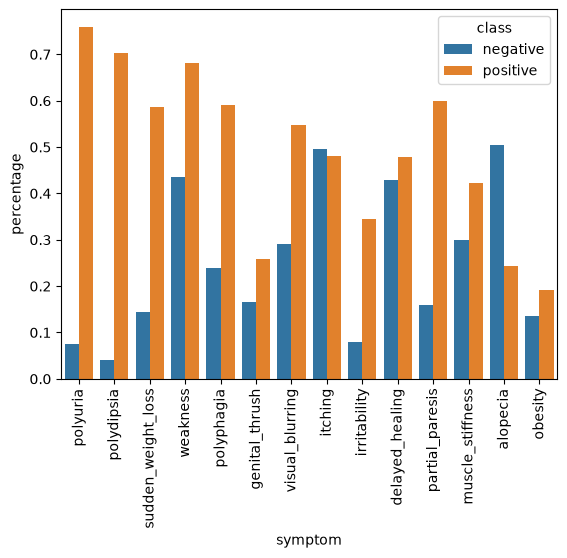

In [37]:
sns.barplot(
    data = df_long,
    x = 'symptom',
    y = 'percentage',
    hue = 'class',
)

plt.xticks(rotation=90)

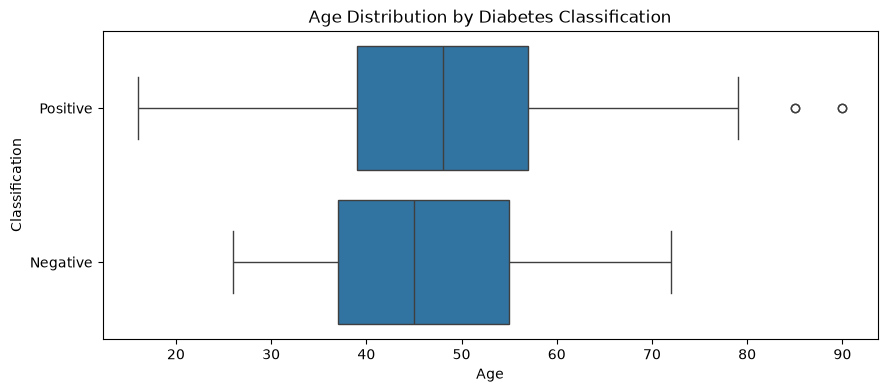

In [38]:
plt.figure(figsize=(10,4))

sns.boxplot(
    data = df,
    y = 'class',
    x = 'age'
)

plt.xlabel("Age")
plt.ylabel('Classification')
plt.title("Age Distribution by Diabetes Classification")

plt.show()

In [39]:
gender_prop = df.groupby('class')['gender'].value_counts(normalize = True)

gender_prop = gender_prop.reset_index(name="percentage")

gender_prop


,class,gender,percentage
0,Negative,Male,0.905000
1,Negative,Female,0.095000
2,Positive,Female,0.540625
3,Positive,Male,0.459375


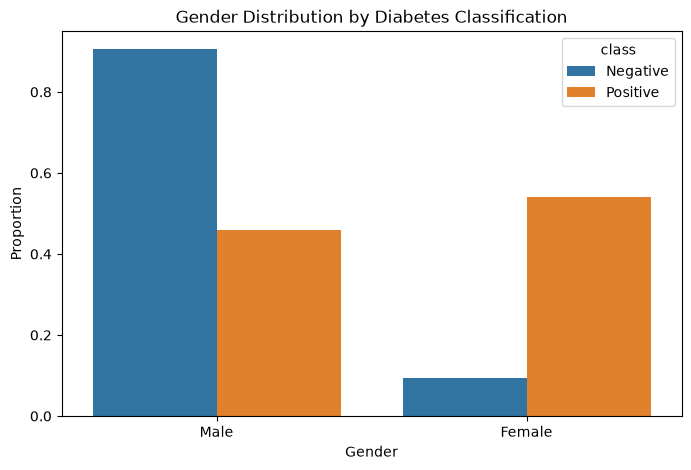

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data = gender_prop,
    x = 'gender',
    y = 'percentage',
    hue = 'class'
)

plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.title("Gender Distribution by Diabetes Classification")

plt.show()

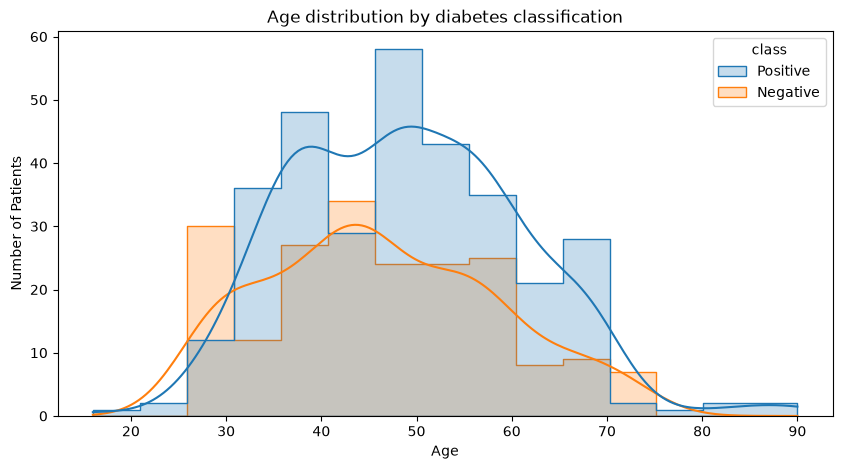

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    data = df,
    x = 'age',
    hue = 'class',
    bins = 15,
    kde = True,
    element = "step"
)

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age distribution by diabetes classification")

plt.show()

In [42]:
# Age alone appears to have limited ability to distinguish Positive from Negative patients because the two age distributions overlap substantially.

In [43]:
top5 = df2.head()

top5

,symptom,negative_grp,positive_grp,difference
0,polyuria,0.075,0.759375,0.684375
1,polydipsia,0.040,0.703125,0.663125
2,sudden_weight_loss,0.145,0.587500,0.442500
3,weakness,0.435,0.681250,0.246250
4,polyphagia,0.240,0.590625,0.350625


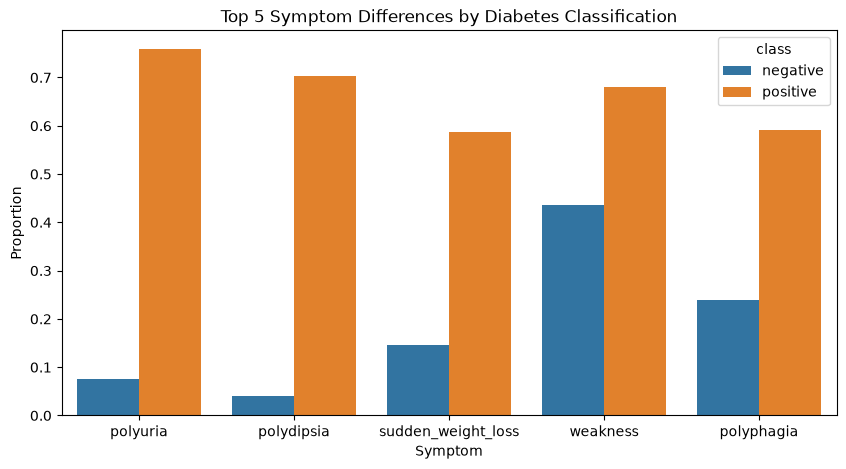

In [44]:
top5_long = top5.melt(
    id_vars='symptom',
    value_vars=['negative_grp','positive_grp'],
    var_name = 'class',
    value_name = 'percentage'
)

top5_long['class'] = top5_long['class'].replace({
    'negative_grp':'negative',
    'positive_grp':'positive'
})

plt.figure(figsize=(10,5))

sns.barplot(
    data = top5_long,
    x='symptom',
    y='percentage',
    hue = 'class'
)

plt.xlabel('Symptom')
plt.ylabel('Proportion')
plt.title('Top 5 Symptom Differences by Diabetes Classification')
plt.xticks()

plt.show()

In [45]:
df2.sort_values('difference')

,symptom,negative_grp,positive_grp,difference
7,itching,0.495,0.481250,0.013750
9,delayed_healing,0.430,0.478125,0.048125
13,obesity,0.135,0.190625,0.055625
5,genital_thrush,0.165,0.259375,0.094375
11,muscle_stiffness,0.300,0.421875,0.121875
3,weakness,0.435,0.681250,0.246250
6,visual_blurring,0.290,0.546875,0.256875
12,alopecia,0.505,0.243750,0.261250
8,irritability,0.080,0.343750,0.263750
4,polyphagia,0.240,0.590625,0.350625


In [46]:
symptom_prevalence = (
    df.drop(columns=['age','gender','class'])
      .apply(lambda x: (x == 'Yes').mean())
      .sort_values(ascending = False)
)

symptom_prevalence

weakness              0.586538
polyuria              0.496154
itching               0.486538
delayed_healing       0.459615
polyphagia            0.455769
polydipsia            0.448077
visual_blurring       0.448077
partial_paresis       0.430769
sudden_weight_loss    0.417308
muscle_stiffness      0.375000
alopecia              0.344231
irritability          0.242308
genital_thrush        0.223077
obesity               0.169231
dtype: float64

In [47]:
# Overall prevalence alone does not indicate how useful a symptom is for distinguishing diabetes classifications.
# A symptom can be very common overall while occurring at similar rates in both groups, making it less useful for distinguishing between them.

In [48]:
df_numeric = df.copy()

df_numeric = df_numeric.replace({
    'Yes': 1,
    'No' : 0, 
    'Positive' : 1,
    'Negative' : 0
})

df_numeric.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [49]:
df_numeric['class'] = pd.to_numeric(df_numeric['class'])
df_numeric['class'].dtype

correlations = (
    df_numeric.corr(numeric_only=True)["class"]
    .sort_values(ascending=False)
)

correlations

class    1.000000
age      0.108679
Name: class, dtype: float64

In [50]:
df_numeric.dtypes

age                    int64
gender                   str
polyuria              object
polydipsia            object
sudden_weight_loss    object
weakness              object
polyphagia            object
genital_thrush        object
visual_blurring       object
itching               object
irritability          object
delayed_healing       object
partial_paresis       object
muscle_stiffness      object
alopecia              object
obesity               object
class                  int64
dtype: object

In [51]:
symptom_columns = df_numeric.columns.difference(
    ["age", "gender", "class"]
)

df_numeric[symptom_columns] = df_numeric[symptom_columns].apply(
    pd.to_numeric
)

df_numeric.dtypes

age                   int64
gender                  str
polyuria              int64
polydipsia            int64
sudden_weight_loss    int64
weakness              int64
polyphagia            int64
genital_thrush        int64
visual_blurring       int64
itching               int64
irritability          int64
delayed_healing       int64
partial_paresis       int64
muscle_stiffness      int64
alopecia              int64
obesity               int64
class                 int64
dtype: object

In [52]:
correlations = (
    df_numeric.corr(numeric_only=True)["class"]
    .sort_values(ascending=False)
)

correlations

class                 1.000000
polyuria              0.665922
polydipsia            0.648734
sudden_weight_loss    0.436568
partial_paresis       0.432288
polyphagia            0.342504
irritability          0.299467
visual_blurring       0.251300
weakness              0.243275
muscle_stiffness      0.122474
genital_thrush        0.110288
age                   0.108679
obesity               0.072173
delayed_healing       0.046980
itching              -0.013384
alopecia             -0.267512
Name: class, dtype: float64

In [53]:
## 6. Key Findings

'''
### Main Findings

- The dataset contains 520 patients, with 320 classified as Positive and 200 as Negative. This represents a moderate class imbalance that should 
  be considered when interpreting the results.
- The Positive group had a slightly higher average age than the Negative group, however the age distributions overlapped substantially. Therefore 
  age appears to have only a weak association with classification.
- Polyuria and polydipsia showed the strongest differences between the Positive and Negative groups. Their correlations with the Positive
  classification were approximately 0.666 and 0.649, respectively.
- Sudden weight loss and partial paresis also showed relatively strong positive associations with the Positive classification, with correlations 
  of approximately 0.437 and 0.432.
- Weakness had the highest overall prevalence among the symptoms, but its association with classification was considerably weaker than polyuria 
  or polydipsia. This demonstrates that a symptom being common does not necessarily make it a strong indicator of classification.
- Itching showed almost no association with classification, despite being one of the more prevalent symptoms. Its correlation was 
  approximately -0.013.
- Alopecia was more prevalent in the Negative group, resulting in a negative correlation of approximately -0.268 with the Positive classification.
- The percentage-based comparisons and correlation analysis produced broadly consistent results, strengthening the observation that polyuria, 
  polydipsia, sudden weight loss, and partial paresis were among the features most strongly associated with the Positive classification.

### Limitations

- These results describe associations rather than causation. The analysis cannot establish that any symptom causes diabetes.
- The dataset is moderately imbalanced toward the Positive classification, which should be considered when interpreting percentages and 
  evaluating future predictive models.
- The analysis is exploratory and does not establish how accurately these features could classify new patients.
- Further analysis could involve building and evaluating classification models to determine whether these features can accurately predict the 
  classification of unseen patients.

'''

'\n### Main Findings\n\n- The dataset contains 520 patients, with 320 classified as Positive and 200 as Negative. This represents a moderate class imbalance that should \n  be considered when interpreting the results.\n- The Positive group had a slightly higher average age than the Negative group, however the age distributions overlapped substantially. Therefore \n  age appears to have only a weak association with classification.\n- Polyuria and polydipsia showed the strongest differences between the Positive and Negative groups. Their correlations with the Positive\n  classification were approximately 0.666 and 0.649, respectively.\n- Sudden weight loss and partial paresis also showed relatively strong positive associations with the Positive classification, with correlations \n  of approximately 0.437 and 0.432.\n- Weakness had the highest overall prevalence among the symptoms, but its association with classification was considerably weaker than polyuria \n  or polydipsia. This demons